# 08 — Posture and Free-Running Motion

## What this notebook is for

Understanding what the orientation and motion sensors actually contain, and whether the
differences between people are visible in them. It does not rank features or decide what
goes into a model — with six participants and overlapping windows, any number here is too
fragile to carry that weight. The plots are the output.

Notebook 05 looked at the 300ms around each tap. This one looks at **everything else**:
roughly 45,000 orientation and 45,000 motion samples describing how the phone is held
between interactions.

## What the three orientation angles mean

Worth being concrete, because the names are unhelpful and the physical meaning drives
every interpretation below.

| angle | axis | what it measures | typical value here |
|---|---|---|---|
| **beta** | front–back | how far the top of the phone tips away from you | 40–70° |
| **gamma** | left–right | how far the phone rolls about its long axis | −9° to +5° |
| **alpha** | compass | which way the phone points relative to north | 0–360°, wraps |

Beta is mostly **where you are sitting** — upright in a chair versus reclined on a sofa.
Gamma is mostly **how you hold it** — a hand that habitually rotates the phone slightly.
Alpha is **which way you were facing**, which is about the room, not the person.

Motion is separate: `ax/ay/az` are linear acceleration with gravity removed, so they
measure movement rather than attitude.

## Sections

1. What is in the streams, and how fast they sample
2. Posture over a session — the raw traces
3. Posture distributions, per session and per person
4. The same person across their own sessions
5. Movement: what "holding still" looks like
6. Who can be measured, and who cannot
7. Restlessness while not interacting
8. Frequency content
9. The alpha wrap, and why circular means are necessary
10. Two sensors, one quantity: a consistency check
11. Per-participant summary
12. Data-quality notes and open questions


## 1. What is in the streams

In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, FancyArrow

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 210)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                     'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

RAW_EVENTS_PARQUET = "../../data/processed/raw_events.parquet"
RAW_EVENTS_CSV = "../../data/processed/raw_events.csv"
if Path(RAW_EVENTS_PARQUET).exists():
    raw_all = pd.read_parquet(RAW_EVENTS_PARQUET); _src = RAW_EVENTS_PARQUET
else:
    raw_all = pd.read_csv(RAW_EVENTS_CSV, low_memory=False); _src = RAW_EVENTS_CSV

raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

ORIENT_KIND, MOTION_KIND = 'deviceorientation', 'devicemotion'
ACCEL_COLS = ['payload_ax', 'payload_ay', 'payload_az']
GRAVITY_COLS = ['payload_agx', 'payload_agy', 'payload_agz']
INTERACTION_KINDS = ['keydown', 'keyup', 'input', 'touchstart', 'touchmove', 'touchend',
                     'scroll', 'window_scroll', 'carousel_scroll', 'pointerdown',
                     'pointerup', 'click']
ANGLES = {'payload_beta': 'beta — front/back tilt',
          'payload_gamma': 'gamma — left/right roll'}

session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                 .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                      started=('timestampIso', 'min')).reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['session_no'] = session_index.groupby('participantId').cumcount() + 1
SESSION_LABEL = {r.sessionId: f"{r.participantId} s{r.session_no}" for r in session_index.itertuples()}
SESSION_ORDER = session_index.sort_values(['participantId', 'session_no'])['sessionId'].tolist()

_p_dur = session_index.groupby('participantId')['duration_s'].median().sort_values(ascending=False)
PARTICIPANTS = _p_dur.index.astype(str).tolist()   # slowest session first
PCOL = {p: plt.get_cmap('turbo')((i + 0.5) / max(1, len(PARTICIPANTS)))
        for i, p in enumerate(PARTICIPANTS)}
def pcolor(p): return PCOL.get(str(p), '0.5')

inventory = (raw.loc[raw['kind'].isin([ORIENT_KIND, MOTION_KIND])]
             .groupby(['participantId', 'kind']).size().unstack(fill_value=0)
             .reindex(PARTICIPANTS))
inventory['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
inventory['total_minutes'] = (session_index.groupby('participantId')['duration_s'].sum()
                              .reindex(PARTICIPANTS) / 60).round(1)

print(f"Loaded {_src}")
print(f"mobile only: {raw['sessionId'].nunique()} sessions, {len(PARTICIPANTS)} participants\n")
print(inventory.to_string())

Loaded ../../data/processed/raw_events.parquet
mobile only: 13 sessions, 6 participants

kind           devicemotion  deviceorientation  sessions  total_minutes
participantId                                                          
p3M6E7Z               14353              14278         1           15.9
pH3S4X4               19079              18816         3           27.1
pZMC82M                5635               5568         1            7.3
p3YDMHG               10798              10668         2           11.9
pA6XL23                9287               9232         2           10.6
pG5G4MS                7812               7731         4            9.5


### 1.1 How fast do the sensors sample, and what does that cost us?

Sampling rate sets a hard ceiling on what can be seen. Anything oscillating faster than
half the sampling rate — the Nyquist frequency — cannot be represented and gets folded
back into the signal as a false lower frequency.

That matters here because hand tremor lives at roughly 8–12 Hz. The plot below shows
where the sampling limit falls relative to that band.

              min  median   max
stream                         
motion       20.0    20.0  20.0
orientation  20.0    20.0  20.0

At 20 Hz the Nyquist limit is 10 Hz.
Hand tremor sits at 8-12 Hz, so it is at or beyond the limit: any energy seen up
there is partly real and partly aliased from higher frequencies. Read it as a
rough indicator of 'how much fast wobble', not as a tremor measurement.


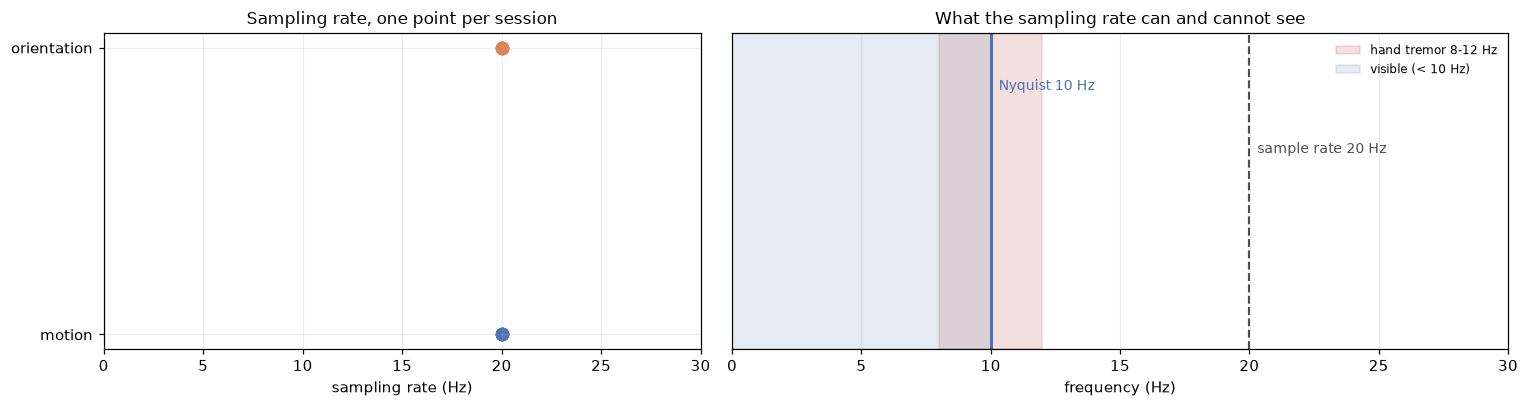

In [20]:
_rates = []
for sid, g in raw.groupby('sessionId'):
    for kind, label in ((MOTION_KIND, 'motion'), (ORIENT_KIND, 'orientation')):
        t = np.sort(g.loc[g['kind'] == kind, 'tRelMs'].to_numpy(float))
        if len(t) < 20:
            continue
        d = np.diff(t); d = d[(d > 0) & (d < 1000)]
        _rates.append({'sessionId': sid, 'stream': label, 'n': len(t),
                       'median_dt_ms': float(np.median(d)), 'hz': 1000.0 / float(np.median(d))})
rates = pd.DataFrame(_rates)
SAMPLE_HZ = float(rates.loc[rates['stream'] == 'motion', 'hz'].median())
NYQUIST_HZ = SAMPLE_HZ / 2.0


def plot_sampling(rates_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={'width_ratios': [1, 1.3]})
    ax = axes[0]
    for i, (stream, g) in enumerate(rates_df.groupby('stream')):
        ax.scatter(g['hz'], [i] * len(g), s=60, alpha=0.7,
                   color=['#4c72b0', '#dd8452'][i % 2])
    ax.set_yticks(range(rates_df['stream'].nunique()))
    ax.set_yticklabels(sorted(rates_df['stream'].unique()))
    ax.set_xlabel("sampling rate (Hz)"); ax.set_xlim(0, max(30, rates_df['hz'].max() * 1.2))
    ax.set_title("Sampling rate, one point per session")

    ax = axes[1]
    f = np.linspace(0, 30, 400)
    ax.axvspan(8, 12, color='#c44e52', alpha=0.18, label='hand tremor 8-12 Hz')
    ax.axvspan(0, NYQUIST_HZ, color='#4c72b0', alpha=0.14, label=f'visible (< {NYQUIST_HZ:.0f} Hz)')
    ax.axvline(NYQUIST_HZ, color='#4c72b0', lw=2)
    ax.axvline(SAMPLE_HZ, color='0.3', ls='--', lw=1.4)
    ax.text(NYQUIST_HZ, 0.82, f'  Nyquist {NYQUIST_HZ:.0f} Hz', fontsize=9, color='#4c72b0')
    ax.text(SAMPLE_HZ, 0.62, f'  sample rate {SAMPLE_HZ:.0f} Hz', fontsize=9, color='0.3')
    ax.set_yticks([]); ax.set_xlim(0, 30); ax.set_xlabel("frequency (Hz)")
    ax.set_title("What the sampling rate can and cannot see")
    ax.legend(loc='upper right', frameon=False, fontsize=8)
    plt.tight_layout(); plt.show(); plt.close(fig)


print(rates.groupby('stream')['hz'].agg(['min', 'median', 'max']).round(1).to_string())
print(f"\nAt {SAMPLE_HZ:.0f} Hz the Nyquist limit is {NYQUIST_HZ:.0f} Hz.")
print("Hand tremor sits at 8-12 Hz, so it is at or beyond the limit: any energy seen up")
print("there is partly real and partly aliased from higher frequencies. Read it as a")
print("rough indicator of 'how much fast wobble', not as a tremor measurement.")
plot_sampling(rates)

## 2. Posture over a session — the raw traces

The most direct view: every orientation sample, unsmoothed, for every session.

What to look for is whether the lines are **flat**. A flat line means the phone stayed at
one angle for the whole session. A ramp would mean gradual slumping; a step would mean the
person repositioned.

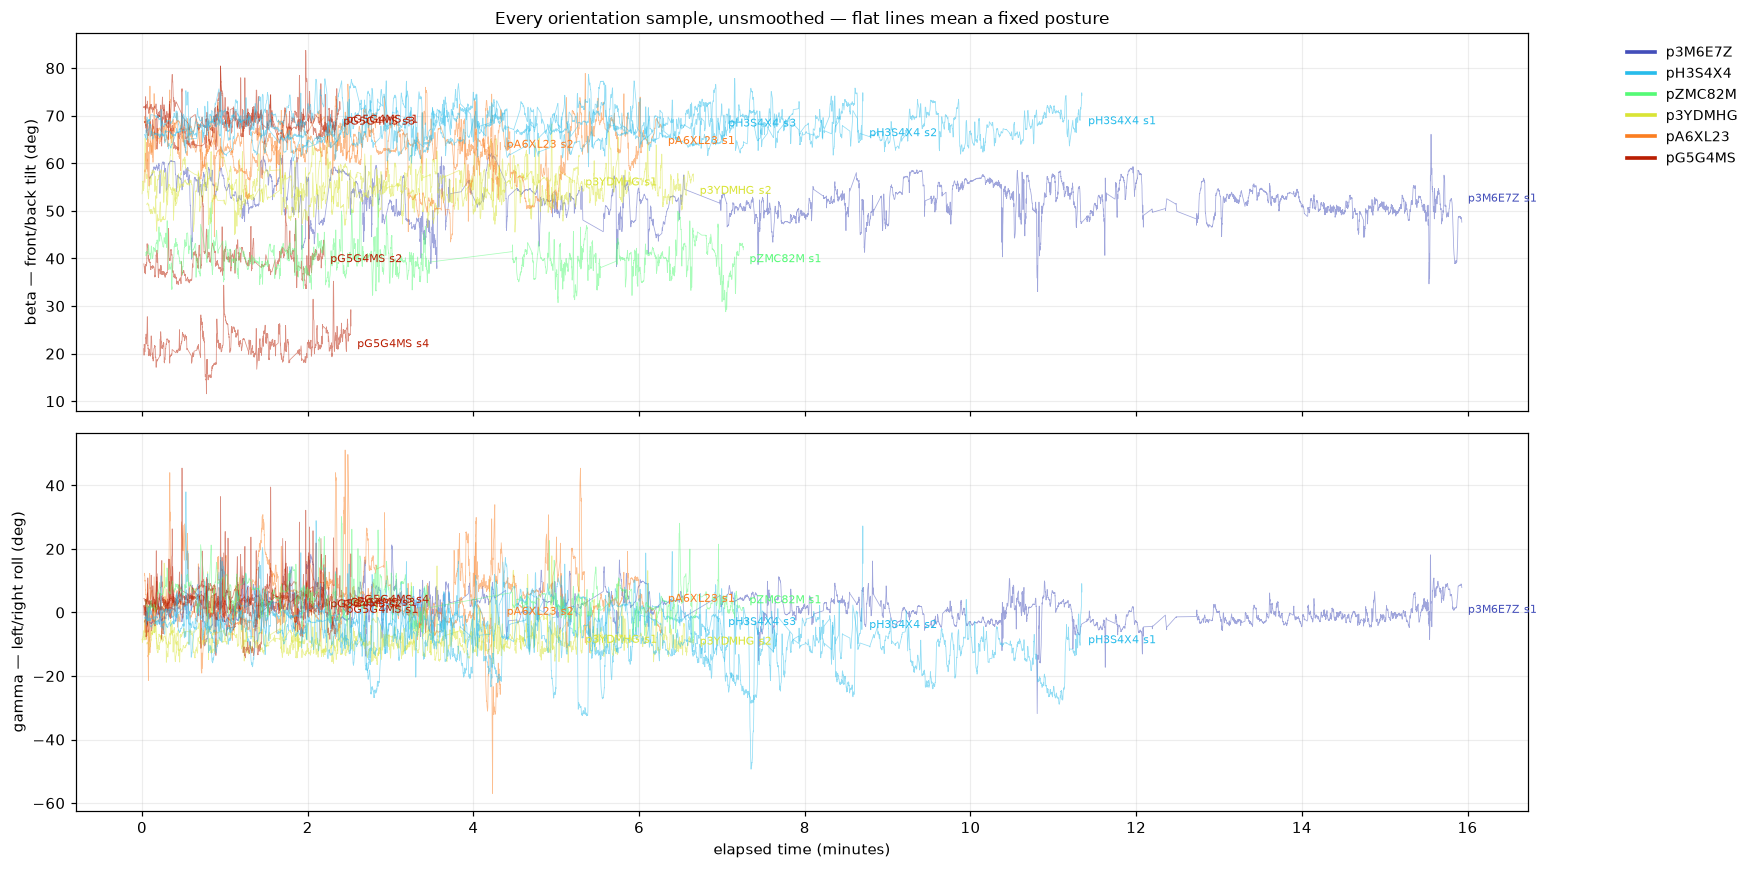

In [21]:
MIN_ORIENT = 300


def plot_raw_traces(raw_df):
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    for ax, (col, name) in zip(axes, ANGLES.items()):
        for sid in SESSION_ORDER:
            s = raw_df.loc[raw_df['sessionId'] == sid]
            o = s.loc[s['kind'] == ORIENT_KIND].sort_values('tRelMs')
            v = pd.to_numeric(o[col], errors='coerce').to_numpy(float)
            t = o['tRelMs'].to_numpy(float) / 60000.0
            ok = np.isfinite(v)
            if ok.sum() < MIN_ORIENT:
                continue
            p = s['participantId'].iloc[0]
            ax.plot(t[ok], v[ok], color=pcolor(p), lw=0.5, alpha=0.5, rasterized=True)
            ax.annotate(SESSION_LABEL.get(sid, ''), (t[ok][-1], np.median(v[ok])),
                        fontsize=7, color=pcolor(p), xytext=(4, 0),
                        textcoords='offset points', va='center')
        ax.set_ylabel(f"{name} (deg)")
    axes[0].set_title("Every orientation sample, unsmoothed — flat lines mean a fixed posture")
    axes[1].set_xlabel("elapsed time (minutes)")
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    axes[0].legend(handles=handles, bbox_to_anchor=(1.06, 1), loc='upper left', frameon=False)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_raw_traces(raw)

In [22]:
def session_angle_summary(raw_df):
    rows = []
    for sid in SESSION_ORDER:
        s = raw_df.loc[raw_df['sessionId'] == sid]
        o = s.loc[s['kind'] == ORIENT_KIND].sort_values('tRelMs')
        rec = {'session': SESSION_LABEL.get(sid, sid[:8]),
               'participantId': s['participantId'].iloc[0], 'sessionId': sid,
               'minutes': round(s['tRelMs'].max() / 60000.0, 1)}
        for col, name in ANGLES.items():
            v = pd.to_numeric(o[col], errors='coerce').to_numpy(float)
            t = o['tRelMs'].to_numpy(float) / 1000.0
            ok = np.isfinite(v)
            if ok.sum() < MIN_ORIENT:
                continue
            v2, t2 = v[ok], t[ok]
            short = col.split('_')[-1]
            rec[f'{short}_median'] = round(float(np.median(v2)), 1)
            rec[f'{short}_iqr'] = round(float(np.percentile(v2, 75) - np.percentile(v2, 25)), 1)
            rec[f'{short}_quartile_range'] = round(
                float(max(np.median(x) for x in np.array_split(v2, 4))
                      - min(np.median(x) for x in np.array_split(v2, 4))), 1)
            rec[f'{short}_drift_per_min'] = round(float(np.polyfit(t2, v2, 1)[0] * 60), 2)
        rows.append(rec)
    return pd.DataFrame(rows)


angle_summary = session_angle_summary(raw)
print("Per session. 'quartile_range' compares the four quarters of the session to each")
print("other, so it detects repositioning; 'iqr' is the moment-to-moment spread.\n")
print(angle_summary.drop(columns=['sessionId', 'participantId']).to_string(index=False))

Per session. 'quartile_range' compares the four quarters of the session to each
other, so it detects repositioning; 'iqr' is the moment-to-moment spread.

   session  minutes  beta_median  beta_iqr  beta_quartile_range  beta_drift_per_min  gamma_median  gamma_iqr  gamma_quartile_range  gamma_drift_per_min
p3M6E7Z s1     15.9         52.5       5.1                  3.0               -0.18           0.7        5.9                   4.7                -0.26
p3YDMHG s1      5.3         55.9       4.5                  0.2               -0.06          -8.7        4.2                   2.1                -0.24
p3YDMHG s2      6.7         54.2       4.0                  2.4                0.59          -9.3        4.3                   1.5                 0.18
pA6XL23 s1      6.3         64.6       8.2                  8.8               -0.35           4.2        8.4                   5.8                 0.40
pA6XL23 s2      4.3         63.8       3.8                  1.3               -0.20  

## 3. Distributions — per session and per person

The traces show flat lines; the distributions show how tightly. A person holding one
posture gives a narrow peak. Two narrow peaks in different places, across sessions, means
the posture changed between visits rather than during one.

The right panel pools each participant's sessions together, which is what a model would
see if it treated posture as a personal characteristic.

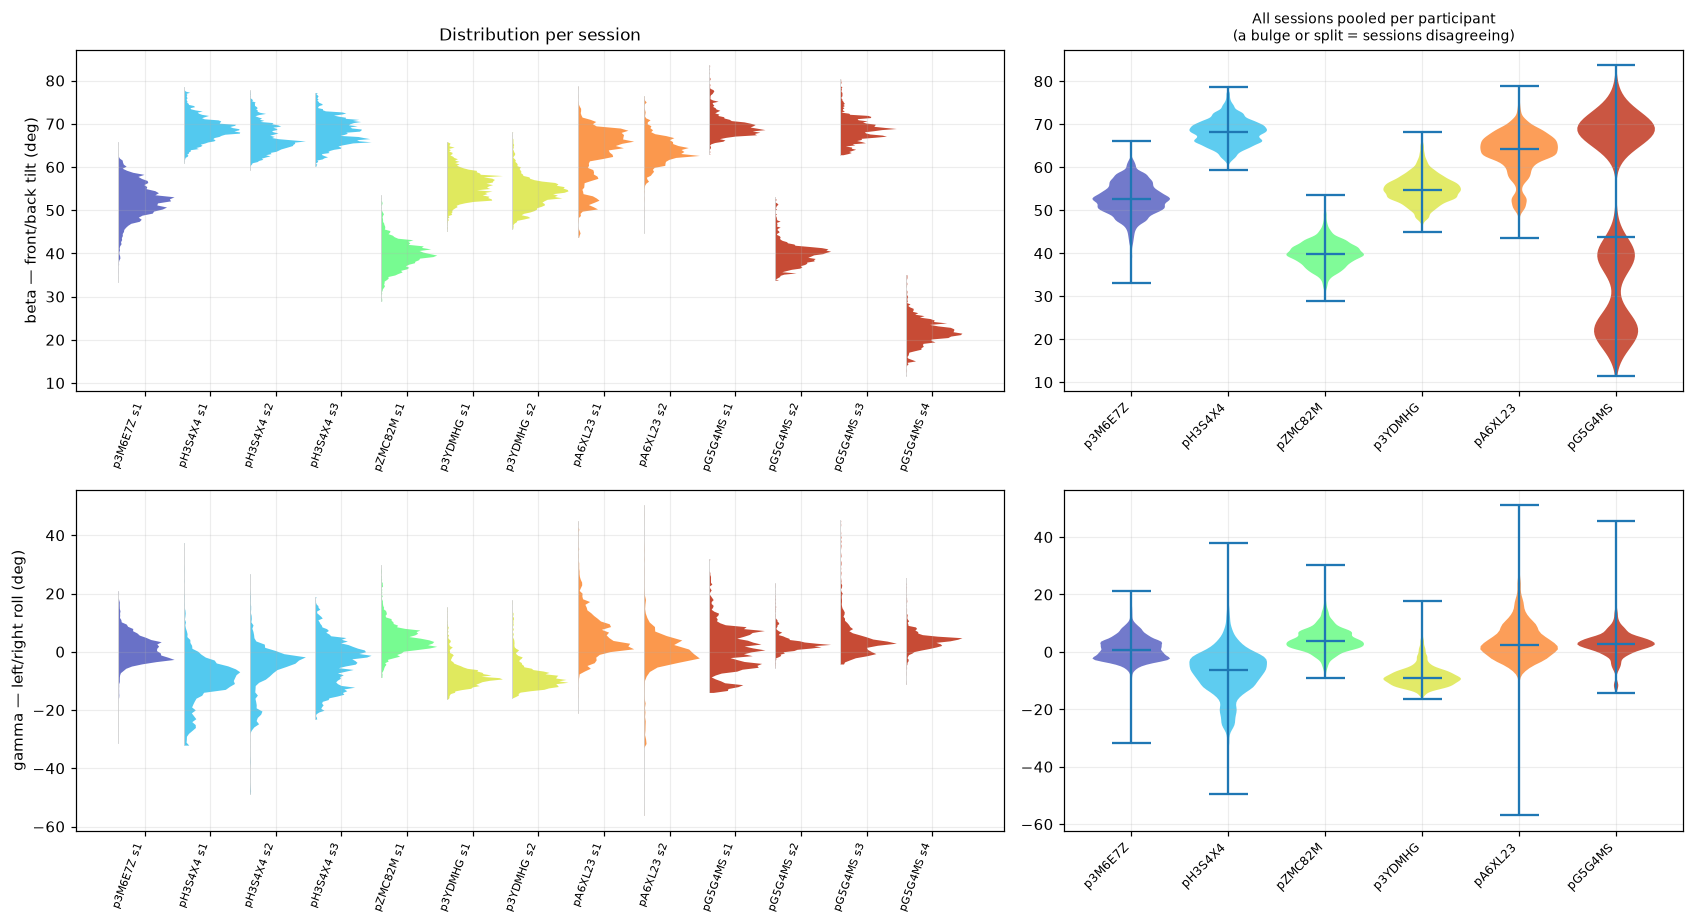

In [23]:
def plot_distributions(raw_df):
    fig, axes = plt.subplots(2, 2, figsize=(15.5, 8.5), gridspec_kw={'width_ratios': [1.5, 1]})
    for row, (col, name) in enumerate(ANGLES.items()):
        # per-session ridgelines
        ax = axes[row, 0]
        labels, offset = [], 0
        for p in PARTICIPANTS:
            for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
                v = pd.to_numeric(raw_df.loc[(raw_df['sessionId'] == sid)
                                             & (raw_df['kind'] == ORIENT_KIND), col],
                                  errors='coerce').dropna().to_numpy()
                if len(v) < MIN_ORIENT:
                    continue
                hist, edges = np.histogram(v, bins=70, density=True)
                if hist.max() > 0:
                    hist = hist / hist.max() * 0.85
                mids = (edges[:-1] + edges[1:]) / 2
                ax.fill_betweenx(mids, offset, offset + hist, color=pcolor(p), alpha=0.8, lw=0)
                ax.plot([offset, offset], [mids.min(), mids.max()], color='0.8', lw=0.5)
                labels.append(SESSION_LABEL.get(sid, sid[:6])); offset += 1
        ax.set_xticks(np.arange(len(labels)) + 0.4)
        ax.set_xticklabels(labels, rotation=70, ha='right', fontsize=7)
        ax.set_ylabel(f"{name} (deg)")
        if row == 0:
            ax.set_title("Distribution per session")

        # pooled per participant
        ax = axes[row, 1]
        data, names, colors = [], [], []
        for p in PARTICIPANTS:
            v = pd.to_numeric(raw_df.loc[(raw_df['participantId'] == p)
                                         & (raw_df['kind'] == ORIENT_KIND), col],
                              errors='coerce').dropna().to_numpy()
            if len(v) < MIN_ORIENT:
                continue
            data.append(v); names.append(p); colors.append(pcolor(p))
        parts = ax.violinplot(data, showmedians=True, widths=0.8)
        for body, c in zip(parts['bodies'], colors):
            body.set_facecolor(c); body.set_alpha(0.75)
        ax.set_xticks(range(1, len(names) + 1))
        ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
        if row == 0:
            ax.set_title("All sessions pooled per participant\n(a bulge or split = sessions "
                         "disagreeing)", fontsize=9)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_distributions(raw)

## 4. The same person, across their own sessions

The observation worth understanding from this notebook.

Posture is essentially **fixed within a session** and can be **completely different between
sessions**. Below, each participant's sessions are overlaid: same colour, different line
style. Where the lines sit on top of each other, that person held the phone the same way
on both visits. Where they separate, they did not.

This matters for two reasons. It means posture describes **the recording** at least as much
as the person — so a window's session is often readable from its tilt alone. And it means
any evaluation that mixes windows from one session across training and testing will get
credit for recognising the session rather than the person. P1's session-safe splits already
prevent that; it's worth knowing what they are preventing.

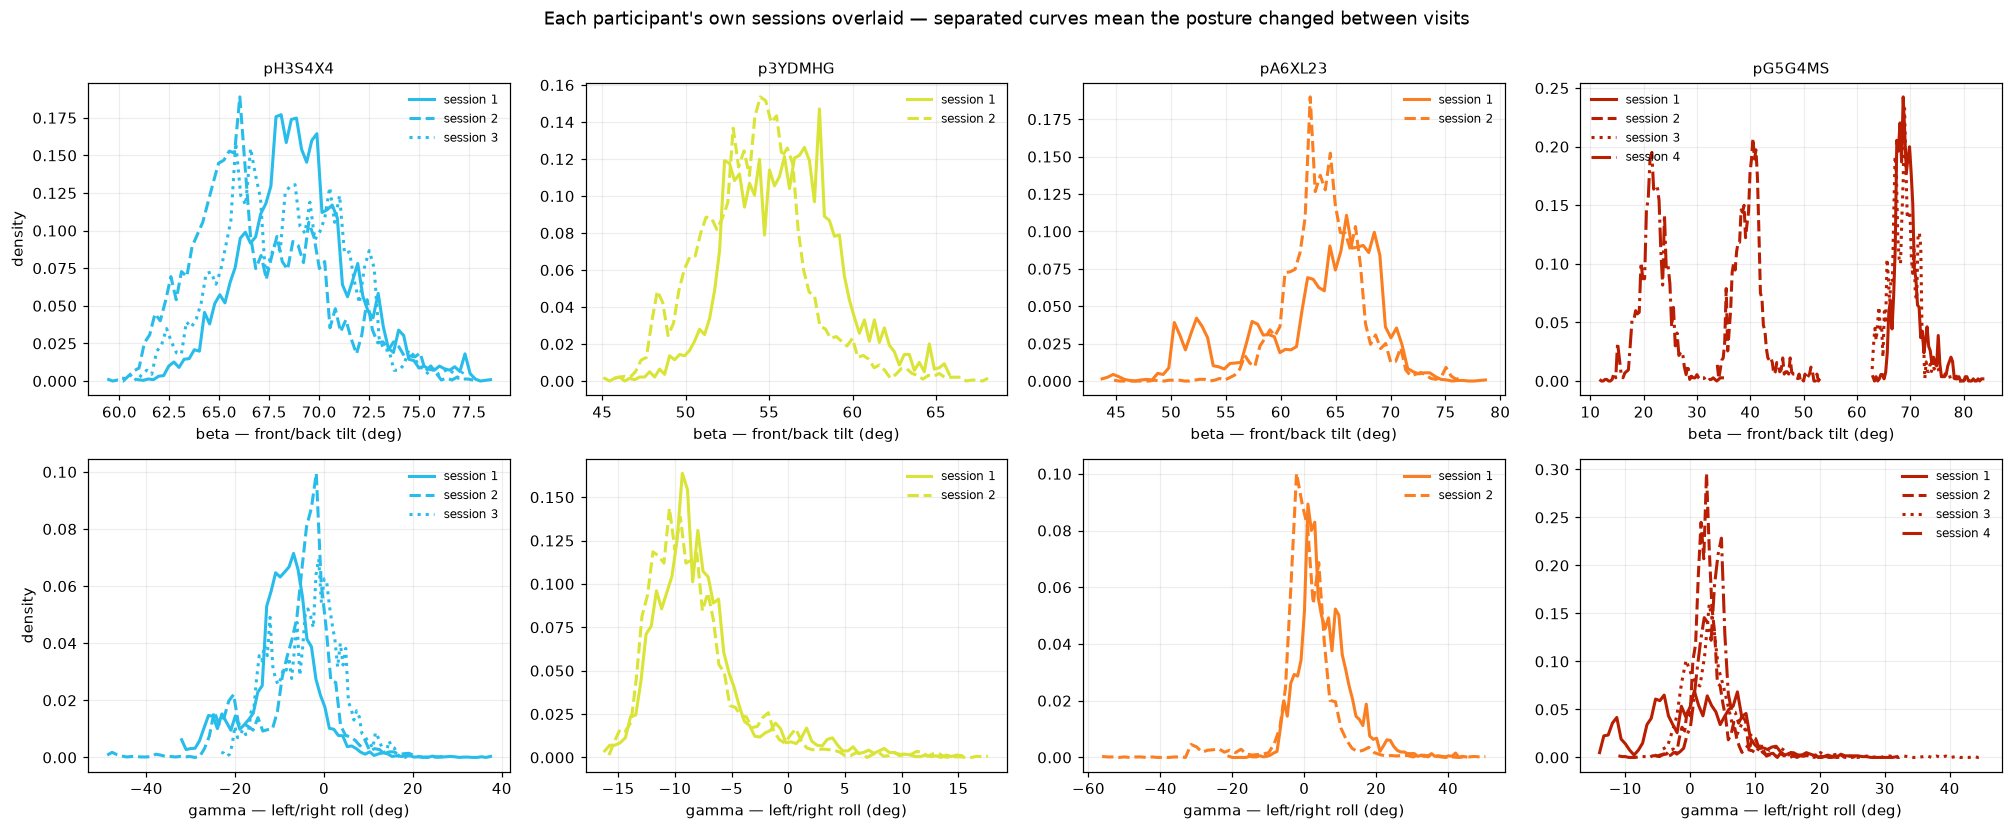

single-session participants (no comparison possible): p3M6E7Z, pZMC82M


In [24]:
def plot_same_person(raw_df):
    reps = [p for p in PARTICIPANTS
            if session_index.loc[session_index['participantId'] == p, 'sessionId'].nunique() > 1]
    singles = [p for p in PARTICIPANTS if p not in reps]
    n = len(reps)
    fig, axes = plt.subplots(2, max(n, 1), figsize=(4.6 * max(n, 1), 7.5), squeeze=False)
    styles = ['-', '--', ':', '-.']
    for j, p in enumerate(reps):
        sids = session_index.loc[session_index['participantId'] == p, 'sessionId'].tolist()
        for row, (col, name) in enumerate(ANGLES.items()):
            ax = axes[row, j]
            for k, sid in enumerate(sids):
                v = pd.to_numeric(raw_df.loc[(raw_df['sessionId'] == sid)
                                             & (raw_df['kind'] == ORIENT_KIND), col],
                                  errors='coerce').dropna().to_numpy()
                if len(v) < MIN_ORIENT:
                    continue
                hist, edges = np.histogram(v, bins=70, density=True)
                mids = (edges[:-1] + edges[1:]) / 2
                ax.plot(mids, hist, color=pcolor(p), ls=styles[k % len(styles)], lw=2,
                        label=f"session {k + 1}")
            ax.set_xlabel(f"{name} (deg)")
            if row == 0:
                ax.set_title(p, fontsize=10)
            if j == 0:
                ax.set_ylabel("density")
            ax.legend(frameon=False, fontsize=8)
    fig.suptitle("Each participant's own sessions overlaid — separated curves mean the "
                 "posture changed between visits", y=1.0)
    plt.tight_layout(); plt.show(); plt.close(fig)
    if singles:
        print(f"single-session participants (no comparison possible): {', '.join(singles)}")


plot_same_person(raw)

1,851 windows with at least 20 orientation samples

Each cluster below is a session. Where one colour forms two separate clusters,
that participant sat differently on their two visits.


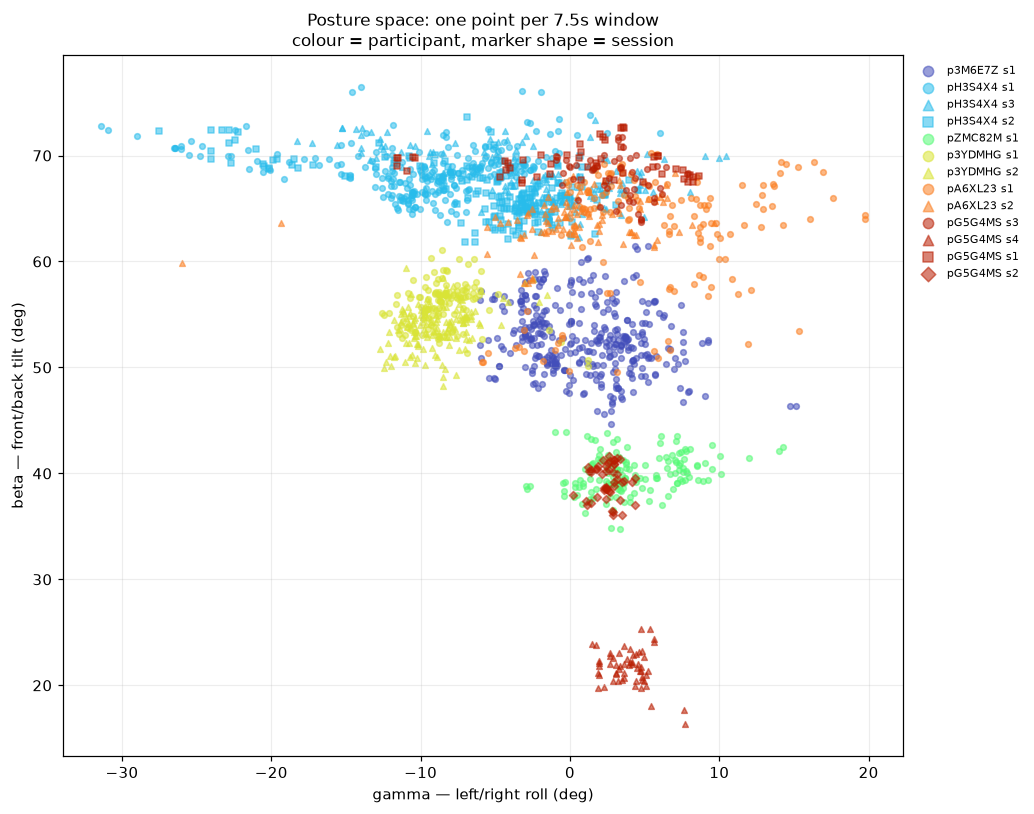

In [25]:
CA_WINDOW_S, CA_STRIDE_S = 7.5, 2.5
MIN_ORIENT_PER_WINDOW = 20


def build_windows(raw_df):
    rows = []
    for sid, s in raw_df.groupby('sessionId'):
        o = s.loc[s['kind'] == ORIENT_KIND].sort_values('tRelMs')
        ot = o['tRelMs'].to_numpy(float) / 1000.0
        cols = {c: pd.to_numeric(o[c], errors='coerce').to_numpy(float)
                for c in ['payload_beta', 'payload_gamma', 'payload_alpha']}
        m = s.loc[s['kind'] == MOTION_KIND].sort_values('tRelMs')
        mt = m['tRelMs'].to_numpy(float) / 1000.0
        mag = np.sqrt(sum(pd.to_numeric(m[c], errors='coerce').to_numpy(float) ** 2
                          for c in ACCEL_COLS))
        end = s['tRelMs'].max() / 1000.0
        lo = 0.0
        while lo + CA_WINDOW_S <= end:
            om = (ot >= lo) & (ot < lo + CA_WINDOW_S)
            if om.sum() >= MIN_ORIENT_PER_WINDOW:
                mm = (mt >= lo) & (mt < lo + CA_WINDOW_S)
                rows.append({'participantId': s['participantId'].iloc[0], 'sessionId': sid,
                             'window_start_s': lo,
                             'beta': float(np.nanmedian(cols['payload_beta'][om])),
                             'gamma': float(np.nanmedian(cols['payload_gamma'][om])),
                             'beta_spread': float(np.nanstd(cols['payload_beta'][om])),
                             'motion_median': float(np.nanmedian(mag[mm])) if mm.sum() > 3 else np.nan})
            lo += CA_STRIDE_S
    return pd.DataFrame(rows)


windows = build_windows(raw)


def plot_posture_space(w):
    fig, ax = plt.subplots(figsize=(9.5, 7.5))
    markers = ['o', '^', 's', 'D', 'v']
    for p in PARTICIPANTS:
        d = w.loc[w['participantId'] == p]
        for j, (sid, g) in enumerate(d.groupby('sessionId')):
            ax.scatter(g['gamma'], g['beta'], s=14, alpha=0.55, color=pcolor(p),
                       marker=markers[j % len(markers)], label=SESSION_LABEL.get(sid, ''))
    ax.set_xlabel("gamma — left/right roll (deg)")
    ax.set_ylabel("beta — front/back tilt (deg)")
    ax.set_title("Posture space: one point per 7.5s window\n"
                 "colour = participant, marker shape = session")
    ax.legend(bbox_to_anchor=(1.005, 1), loc='upper left', frameon=False,
              fontsize=7, markerscale=1.8)
    plt.tight_layout(); plt.show(); plt.close(fig)


print(f"{len(windows):,} windows with at least {MIN_ORIENT_PER_WINDOW} orientation samples\n")
print("Each cluster below is a session. Where one colour forms two separate clusters,")
print("that participant sat differently on their two visits.")
plot_posture_space(windows)

## 5. Movement — what "holding still" looks like

Switching from attitude to motion. `ax/ay/az` have gravity removed, so they measure
movement rather than orientation.

A phone in a hand is never truly still; a phone on a table is. That gives a way to tell
the two apart: look at acceleration during moments when nobody is touching the screen. If
the low tail of that distribution approaches zero, something other than a hand was holding
the device.

"Idle" here means no interaction within a second either side.

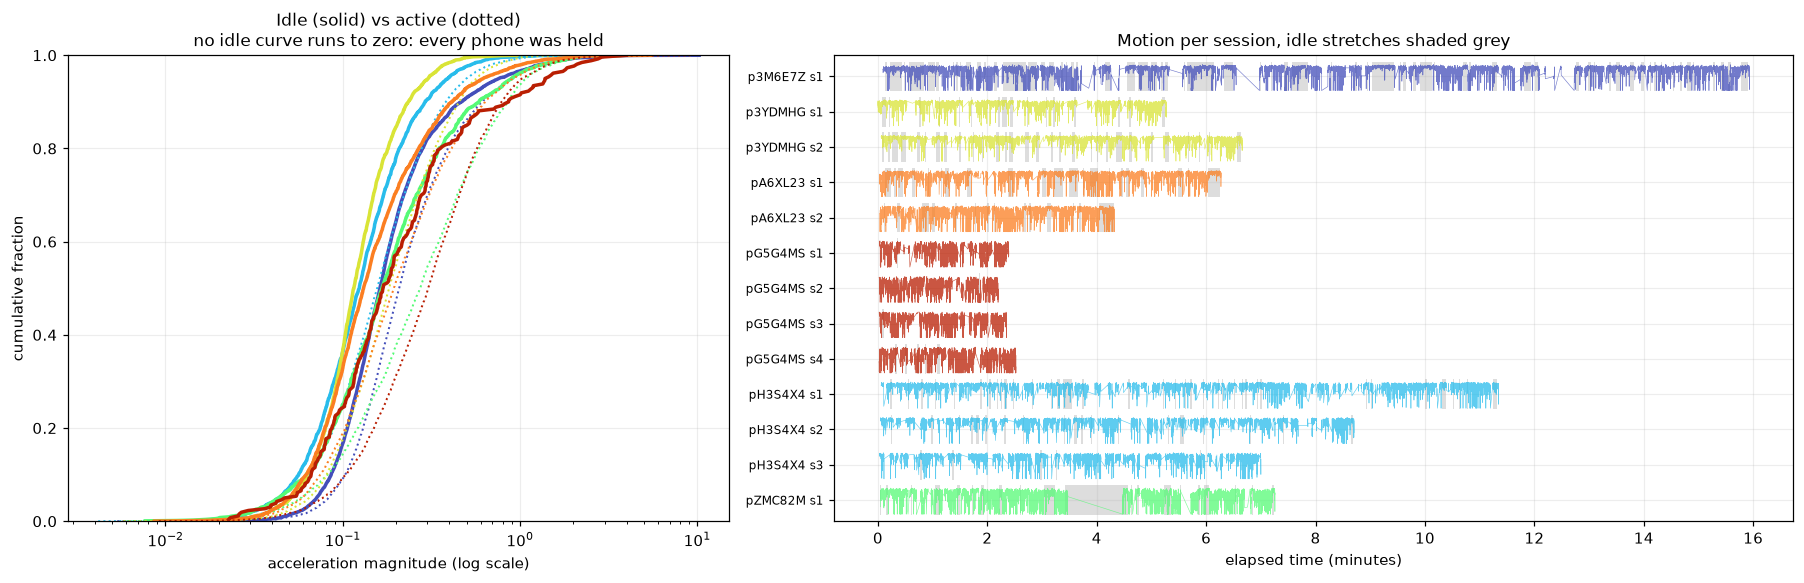

In [26]:
IDLE_GUARD_MS = 1000.0


def idle_mask(sess, motion_t_ms):
    inter = np.sort(sess.loc[sess['kind'].isin(INTERACTION_KINDS), 'tRelMs'].to_numpy(float))
    if len(inter) == 0:
        return np.ones(len(motion_t_ms), bool)
    idx = np.searchsorted(inter, motion_t_ms)
    prev_gap = np.where(idx > 0, motion_t_ms - inter[np.clip(idx - 1, 0, len(inter) - 1)], np.inf)
    next_gap = np.where(idx < len(inter), inter[np.clip(idx, 0, len(inter) - 1)] - motion_t_ms, np.inf)
    return (prev_gap >= IDLE_GUARD_MS) & (next_gap >= IDLE_GUARD_MS)


def motion_arrays(sess):
    m = sess.loc[sess['kind'] == MOTION_KIND].sort_values('tRelMs')
    t = m['tRelMs'].to_numpy(float)
    mag = np.sqrt(sum(pd.to_numeric(m[c], errors='coerce').to_numpy(float) ** 2
                      for c in ACCEL_COLS))
    ok = np.isfinite(mag)
    return t[ok], mag[ok]


def plot_motion(raw_df):
    fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.4), gridspec_kw={'width_ratios': [1, 1.45]})
    ax = axes[0]
    for p in PARTICIPANTS:
        idle_v, act_v = [], []
        for sid, s in raw_df.loc[raw_df['participantId'] == p].groupby('sessionId'):
            t, mag = motion_arrays(s)
            if len(t) < 100:
                continue
            im = idle_mask(s, t)
            idle_v.append(mag[im]); act_v.append(mag[~im])
        for arr, ls, lw in ((idle_v, '-', 2.3), (act_v, ':', 1.3)):
            arr = [a for a in arr if len(a)]
            if not arr:
                continue
            v = np.concatenate(arr); v = v[v > 0]
            if len(v) < 50:
                continue
            ax.plot(np.sort(v), np.arange(1, len(v) + 1) / len(v), color=pcolor(p), ls=ls, lw=lw)
    ax.set_xscale('log'); ax.set_ylim(0, 1)
    ax.set_xlabel("acceleration magnitude (log scale)"); ax.set_ylabel("cumulative fraction")
    ax.set_title("Idle (solid) vs active (dotted)\nno idle curve runs to zero: every phone was held")

    ax = axes[1]
    for row, sid in enumerate(SESSION_ORDER):
        s = raw_df.loc[raw_df['sessionId'] == sid]
        t, mag = motion_arrays(s)
        if len(t) < 100:
            continue
        im = idle_mask(s, t)
        change = np.where(np.diff(im.astype(int)) != 0)[0] + 1
        for run in np.split(np.arange(len(t)), change):
            if len(run) < 10 or not im[run[0]]:
                continue
            ax.fill_between([t[run[0]] / 60000.0, t[run[-1]] / 60000.0],
                            row - 0.42, row + 0.42, color='0.78', alpha=0.6, lw=0, zorder=0)
        ax.plot(t / 60000.0, row + np.clip(mag, 0, 1.0) * 0.75 - 0.35,
                color=pcolor(s['participantId'].iloc[0]), lw=0.4, alpha=0.75,
                rasterized=True, zorder=2)
    ax.set_yticks(range(len(SESSION_ORDER)))
    ax.set_yticklabels([SESSION_LABEL.get(x, x[:6]) for x in SESSION_ORDER], fontsize=8)
    ax.set_ylim(len(SESSION_ORDER) - 0.4, -0.6)
    ax.set_xlabel("elapsed time (minutes)")
    ax.set_title("Motion per session, idle stretches shaded grey")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_motion(raw)

## 6. Who can be measured, and who cannot

Everything in the next two sections needs the person to stop touching the screen for a
few seconds. That is not equally available.

This is a real property of the data rather than a technicality: the participant who never
pauses cannot be described by any idle-based measure, and their absence from those plots
is itself informative about them.

               idle_epochs  idle_seconds  longest_idle_s  session_minutes  idle_pct_of_session
participantId                                                                                 
p3M6E7Z                 32         281.2            29.0             15.9                 29.5
pH3S4X4                  6          27.7             9.3             27.1                  1.7
pZMC82M                  8         109.3            68.6              7.3                 25.0
p3YDMHG                 13          59.7             6.5             11.9                  8.4
pA6XL23                 17         113.8            15.6             10.6                 17.9
pG5G4MS                  1           3.6             3.6              9.5                  0.6


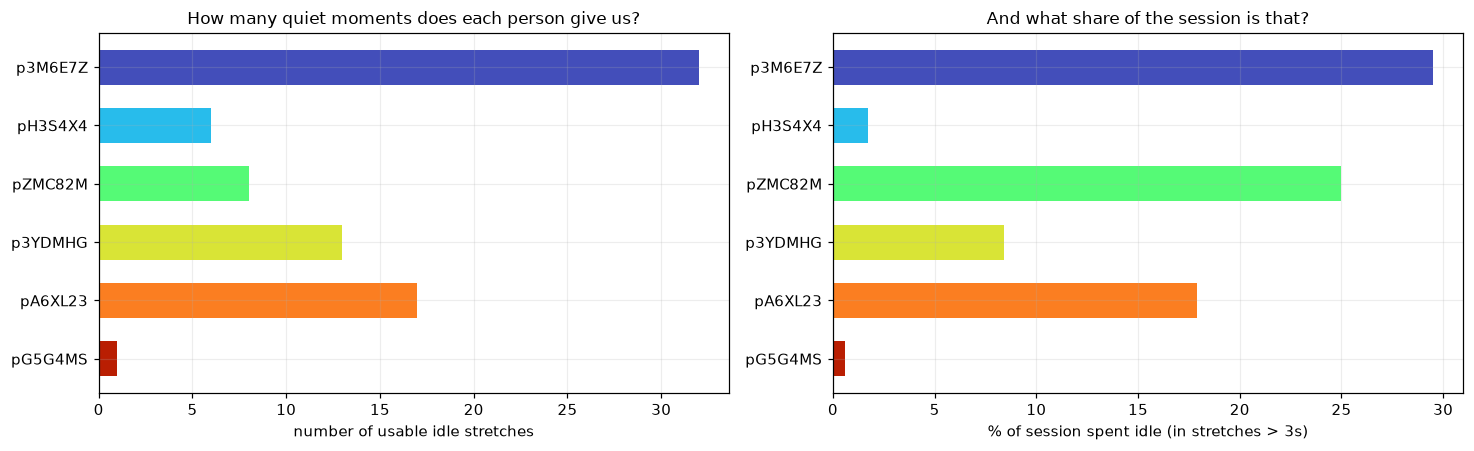

In [27]:
MIN_IDLE_RUN = 60      # samples, roughly 3 s at the observed rate


def idle_runs(raw_df):
    rows = []
    for sid, s in raw_df.groupby('sessionId'):
        t, mag = motion_arrays(s)
        if len(t) < 100:
            continue
        im = idle_mask(s, t)
        change = np.where(np.diff(im.astype(int)) != 0)[0] + 1
        for run in np.split(np.arange(len(t)), change):
            if len(run) < MIN_IDLE_RUN or not im[run[0]]:
                continue
            rows.append({'participantId': s['participantId'].iloc[0], 'sessionId': sid,
                         'start_s': t[run[0]] / 1000.0,
                         'duration_s': (t[run[-1]] - t[run[0]]) / 1000.0,
                         'idx0': run[0], 'idx1': run[-1]})
    return pd.DataFrame(rows)


runs = idle_runs(raw)
avail = (runs.groupby('participantId')
         .agg(idle_epochs=('duration_s', 'size'), idle_seconds=('duration_s', 'sum'),
              longest_idle_s=('duration_s', 'max'))
         .reindex(PARTICIPANTS).fillna(0))
avail['session_minutes'] = (session_index.groupby('participantId')['duration_s'].sum()
                            .reindex(PARTICIPANTS) / 60).round(1)
avail['idle_pct_of_session'] = (avail['idle_seconds'] /
                                (avail['session_minutes'] * 60) * 100).round(1)


def plot_availability(av):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
    ax = axes[0]
    y = np.arange(len(av))
    ax.barh(y, av['idle_epochs'], color=[pcolor(p) for p in av.index], height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(av.index); ax.invert_yaxis()
    ax.set_xlabel("number of usable idle stretches")
    ax.set_title("How many quiet moments does each person give us?")
    for i, p in enumerate(av.index):
        if av.loc[p, 'idle_epochs'] == 0:
            ax.text(0.2, i, "none — cannot be measured", va='center', fontsize=9, color='#c44e52')
    ax = axes[1]
    ax.barh(y, av['idle_pct_of_session'], color=[pcolor(p) for p in av.index], height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(av.index); ax.invert_yaxis()
    ax.set_xlabel("% of session spent idle (in stretches > 3s)")
    ax.set_title("And what share of the session is that?")
    plt.tight_layout(); plt.show(); plt.close(fig)


print(avail.astype({'idle_epochs': int}).round(1).to_string())
plot_availability(avail)

## 7. Restlessness while not interacting

If the phone moves while nobody is touching it, that movement came from the person holding
it — small shifts of grip, hand, or posture. Total angular travel per second during idle
stretches is a plain measure of that.

Two things make this interesting and one makes it awkward.

It is a different quantity from anything else measured in this project: not speed, not
accuracy, not gesture shape, but how much someone moves while doing nothing. And it does
not track session pace, so it is not another way of measuring how fast someone works.

The awkwardness is that it is only defined for people who pause, which excludes the
participant who never does.

77 idle stretches usable, covering 6/6 participants

               angular_travel_deg_s  beta_wander_deg  net_drift_deg
participantId                                                      
p3M6E7Z                        7.03             6.75           1.46
pH3S4X4                        9.94             4.33           1.46
pZMC82M                       10.27             6.85           2.52
p3YDMHG                        4.91             3.86           1.71
pA6XL23                        7.17             5.65           1.92
pG5G4MS                        4.11             2.31           1.72


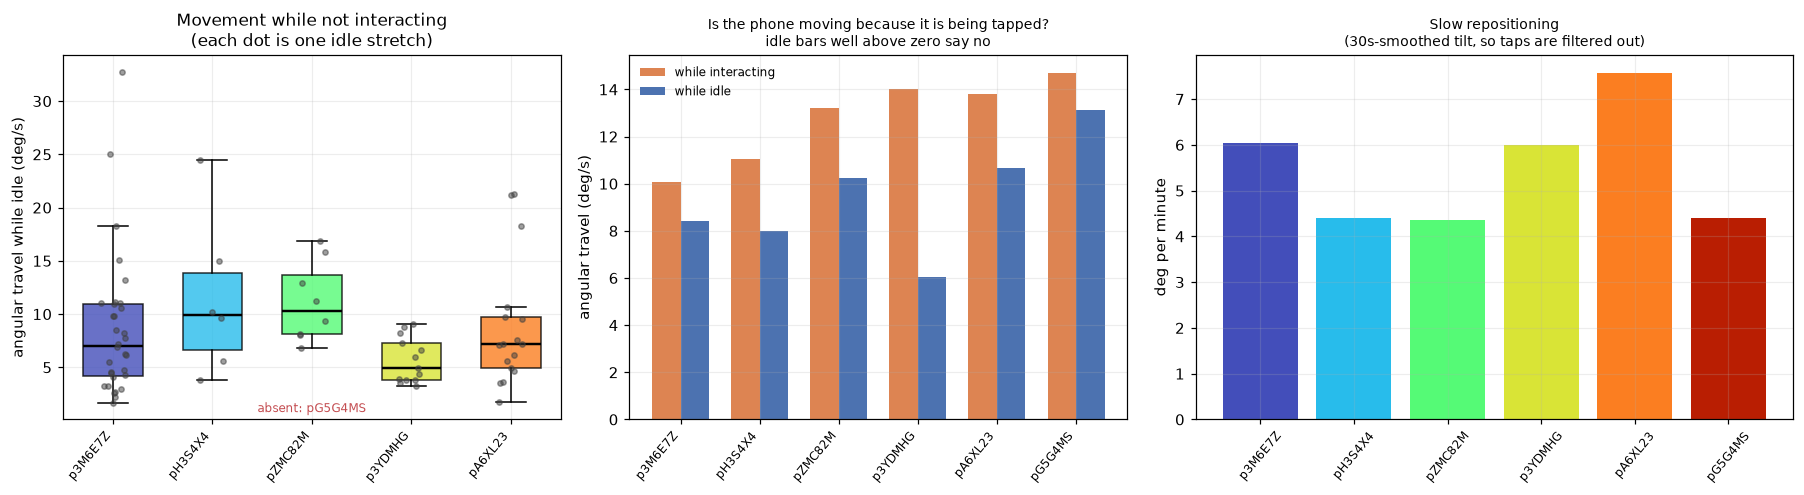

In [28]:
def idle_dynamics(raw_df):
    rows = []
    for sid, s in raw_df.groupby('sessionId'):
        o = s.loc[s['kind'] == ORIENT_KIND].sort_values('tRelMs')
        ot = o['tRelMs'].to_numpy(float)
        beta = pd.to_numeric(o['payload_beta'], errors='coerce').to_numpy(float)
        gamma = pd.to_numeric(o['payload_gamma'], errors='coerce').to_numpy(float)
        ok = np.isfinite(beta) & np.isfinite(gamma)
        ot, beta, gamma = ot[ok], beta[ok], gamma[ok]
        if len(ot) < MIN_ORIENT:
            continue
        for r in runs.loc[runs['sessionId'] == sid].itertuples():
            t0, t1 = r.start_s * 1000, (r.start_s + r.duration_s) * 1000
            m = (ot >= t0) & (ot <= t1)
            if m.sum() < 30:
                continue
            dt = np.diff(ot[m]) / 1000.0
            travel = np.abs(np.diff(beta[m])) + np.abs(np.diff(gamma[m]))
            good = (dt > 0) & (dt < 0.5)
            if good.sum() < 20:
                continue
            rows.append({'participantId': r.participantId, 'sessionId': sid,
                         'duration_s': r.duration_s,
                         'angular_travel_deg_s': float(travel[good].sum() / dt[good].sum()),
                         'beta_wander_deg': float(np.ptp(beta[m])),
                         'net_drift_deg': float(abs(beta[m][-1] - beta[m][0]))})
    return pd.DataFrame(rows)


idle_dyn = idle_dynamics(raw)


def plot_restlessness(dyn, raw_df):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6),
                             gridspec_kw={'width_ratios': [1, 1, 1.2]})
    ax = axes[0]
    data, names, colors = [], [], []
    for p in PARTICIPANTS:
        v = dyn.loc[dyn['participantId'] == p, 'angular_travel_deg_s'].dropna().to_numpy()
        if len(v) < 3:
            continue
        data.append(v); names.append(p); colors.append(pcolor(p))
    missing = [p for p in PARTICIPANTS if p not in names]
    if data:
        bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.6,
                        medianprops={'color': 'black', 'lw': 1.6})
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c); patch.set_alpha(0.8)
        for i, v in enumerate(data):
            ax.scatter(np.full(len(v), i + 1) + np.random.uniform(-0.13, 0.13, len(v)),
                       v, s=12, color='0.25', alpha=0.5, zorder=3)
        ax.set_xticks(range(1, len(names) + 1))
        ax.set_xticklabels(names, rotation=50, ha='right', fontsize=8)
    ax.set_ylabel("angular travel while idle (deg/s)")
    ax.set_title("Movement while not interacting\n(each dot is one idle stretch)")
    if missing:
        ax.text(0.5, 0.02, f"absent: {', '.join(missing)}", transform=ax.transAxes,
                ha='center', fontsize=8, color='#c44e52')

    # is it just interaction? compare active vs idle travel
    ax = axes[1]
    comp = []
    for p in PARTICIPANTS:
        act, idl = [], []
        for sid, s in raw_df.loc[raw_df['participantId'] == p].groupby('sessionId'):
            o = s.loc[s['kind'] == ORIENT_KIND].sort_values('tRelMs')
            ot = o['tRelMs'].to_numpy(float)
            b = pd.to_numeric(o['payload_beta'], errors='coerce').to_numpy(float)
            g = pd.to_numeric(o['payload_gamma'], errors='coerce').to_numpy(float)
            ok = np.isfinite(b) & np.isfinite(g); ot, b, g = ot[ok], b[ok], g[ok]
            if len(ot) < MIN_ORIENT:
                continue
            im = idle_mask(s, ot)
            dt = np.diff(ot) / 1000.0
            travel = np.abs(np.diff(b)) + np.abs(np.diff(g))
            good = (dt > 0) & (dt < 0.5)
            ma, mi = (~im[:-1]) & good, im[:-1] & good
            if ma.sum() > 20:
                act.append(travel[ma].sum() / dt[ma].sum())
            if mi.sum() > 20:
                idl.append(travel[mi].sum() / dt[mi].sum())
        comp.append({'participantId': p,
                     'active': np.mean(act) if act else np.nan,
                     'idle': np.mean(idl) if idl else np.nan})
    comp = pd.DataFrame(comp).set_index('participantId')
    x = np.arange(len(comp)); w = 0.36
    ax.bar(x - w / 2, comp['active'], width=w, label='while interacting', color='#dd8452')
    ax.bar(x + w / 2, comp['idle'], width=w, label='while idle', color='#4c72b0')
    ax.set_xticks(x); ax.set_xticklabels(comp.index, rotation=50, ha='right', fontsize=8)
    ax.set_ylabel("angular travel (deg/s)")
    ax.set_title("Is the phone moving because it is being tapped?\n"
                 "idle bars well above zero say no", fontsize=9)
    ax.legend(frameon=False, fontsize=8)

    # slow repositioning
    ax = axes[2]
    for p in PARTICIPANTS:
        tot = []
        for sid, s in raw_df.loc[raw_df['participantId'] == p].groupby('sessionId'):
            o = s.loc[s['kind'] == ORIENT_KIND].sort_values('tRelMs')
            t = o['tRelMs'].to_numpy(float) / 1000.0
            b = pd.to_numeric(o['payload_beta'], errors='coerce').to_numpy(float)
            ok = np.isfinite(b); t, b = t[ok], b[ok]
            if len(t) < 600:
                continue
            sm = pd.Series(b).rolling(600, min_periods=200, center=True).median().to_numpy()
            v = np.isfinite(sm)
            tot.append(float(np.abs(np.diff(sm[v])).sum() / ((t.max() - t.min()) / 60)))
        if tot:
            ax.bar(p, np.mean(tot), color=pcolor(p))
    ax.set_ylabel("deg per minute")
    ax.tick_params(axis='x', rotation=50, labelsize=8)
    ax.set_title("Slow repositioning\n(30s-smoothed tilt, so taps are filtered out)", fontsize=9)
    plt.tight_layout(); plt.show(); plt.close(fig)


print(f"{len(idle_dyn)} idle stretches usable, covering "
      f"{idle_dyn['participantId'].nunique()}/{len(PARTICIPANTS)} participants\n")
if len(idle_dyn):
    print(idle_dyn.groupby('participantId')[['angular_travel_deg_s', 'beta_wander_deg',
                                             'net_drift_deg']]
          .median().reindex(PARTICIPANTS).round(2).to_string())
plot_restlessness(idle_dyn, raw)

## 8. Frequency content of idle motion

The same idle stretches, viewed as spectra rather than totals. This separates *slow*
movement (drifting posture, a hand settling) from *fast* movement (fine wobble).

Read the shape, not the absolute level, and remember Section 1.1: the right-hand end of
each curve is at or past the sampling limit, so energy there is partly folded down from
frequencies the sensor could never see. The useful comparison is whether one person's
curve is consistently steeper or flatter than another's.

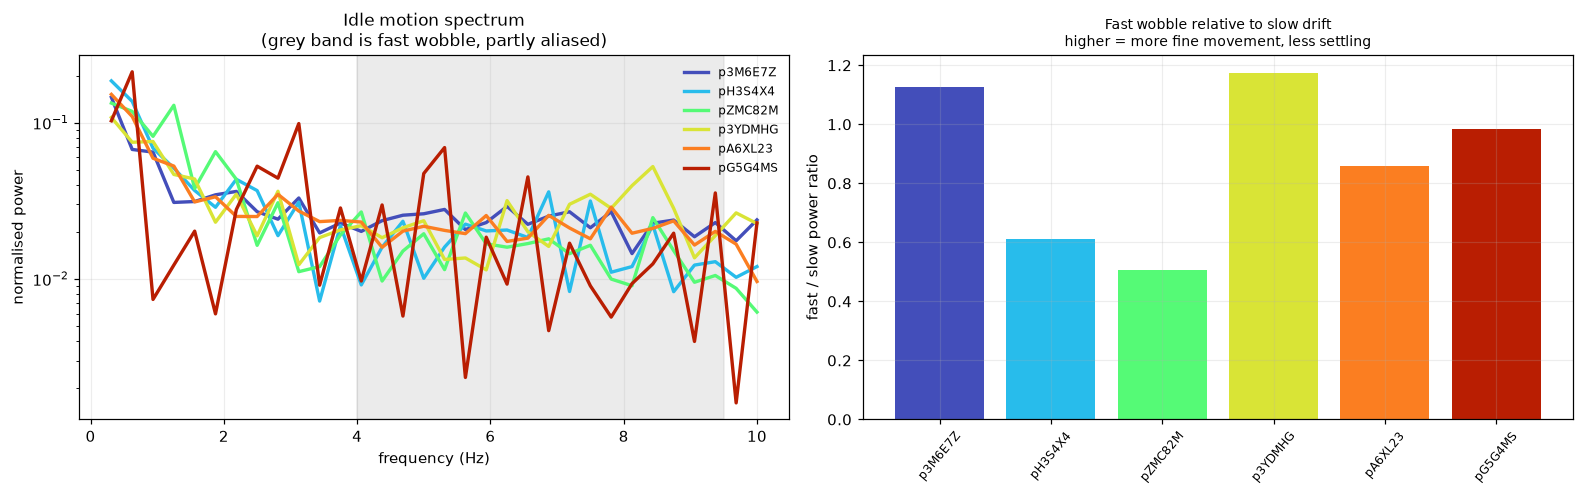

In [29]:
def idle_spectra(raw_df, n_fft=64):
    out = {}
    for p in PARTICIPANTS:
        spec = []
        for sid, s in raw_df.loc[raw_df['participantId'] == p].groupby('sessionId'):
            t, mag = motion_arrays(s)
            if len(t) < 100:
                continue
            im = idle_mask(s, t)
            change = np.where(np.diff(im.astype(int)) != 0)[0] + 1
            for run in np.split(np.arange(len(t)), change):
                if len(run) < n_fft or not im[run[0]]:
                    continue
                x = mag[run][:n_fft]
                x = x - x.mean()
                pw = np.abs(np.fft.rfft(x)) ** 2
                tot = pw[1:].sum()
                if tot > 0:
                    spec.append(pw / tot)
        if spec:
            out[p] = np.mean(spec, axis=0)
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / SAMPLE_HZ)
    return freqs, out


def plot_spectra(raw_df):
    freqs, spec = idle_spectra(raw_df)
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))
    ax = axes[0]
    for p, pw in spec.items():
        ax.plot(freqs[1:], pw[1:], color=pcolor(p), lw=2.2, label=p)
    ax.axvspan(4, min(9.5, NYQUIST_HZ), color='0.75', alpha=0.3, zorder=0)
    ax.set_yscale('log'); ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("normalised power")
    ax.set_title("Idle motion spectrum\n(grey band is fast wobble, partly aliased)")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1]
    lo = (freqs > 0) & (freqs <= 2)
    hi = (freqs >= 4) & (freqs <= min(9.5, NYQUIST_HZ))
    names, ratios, colors = [], [], []
    for p, pw in spec.items():
        names.append(p); colors.append(pcolor(p))
        ratios.append(pw[hi].sum() / pw[lo].sum() if pw[lo].sum() > 0 else np.nan)
    ax.bar(names, ratios, color=colors)
    ax.set_ylabel("fast / slow power ratio")
    ax.tick_params(axis='x', rotation=50, labelsize=8)
    ax.set_title("Fast wobble relative to slow drift\nhigher = more fine movement, "
                 "less settling", fontsize=9)
    missing = [p for p in PARTICIPANTS if p not in spec]
    if missing:
        ax.text(0.5, 0.95, f"absent: {', '.join(missing)}", transform=ax.transAxes,
                ha='center', va='top', fontsize=8, color='#c44e52')
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_spectra(raw)

## 9. The alpha wrap

`alpha` is a compass heading, so it runs 0–360 and jumps between the two ends whenever the
phone passes north. Averaging it arithmetically is wrong in a way that is easy to miss: a
device oscillating around north gives readings near 0 and near 360, and their arithmetic
mean is 180 — pointing the opposite way.

The correct treatment is to convert to a unit vector, average that, and convert back. The
polar plots below show both answers on the same dial.

Alpha also describes the room rather than the person — which way they happened to be
facing — so it is not obviously useful as behaviour. It is here because the wrap is a
general trap that applies to any circular quantity, and this is a clear demonstration
of it.

   session     n  wraps  naive_mean  circular_mean  error_deg
p3M6E7Z s1 14278    137       263.4          354.5       91.1
p3YDMHG s1  4656     66       221.4          359.1      137.7
p3YDMHG s2  6012    117       124.1            2.4      121.7
pA6XL23 s1  5406     91       117.0            5.0      112.0
pA6XL23 s2  3826     66       335.7          353.4       17.7
pG5G4MS s1  1809     47       269.5          354.6       85.2
pG5G4MS s2  1818     24       313.6          357.4       43.8
pG5G4MS s3  1936     52       316.5          356.1       39.6
pG5G4MS s4  2168     20       319.0          356.4       37.4
pH3S4X4 s1  8656    107        42.3            8.0       34.2
pH3S4X4 s2  5641    120       123.2            5.7      117.5
pH3S4X4 s3  4519     74       102.5            7.0       95.5
pZMC82M s1  5568     98       282.9          357.2       74.3

total wraps: 1019 — every session crosses north repeatedly
worst error from naive averaging: 138 degrees


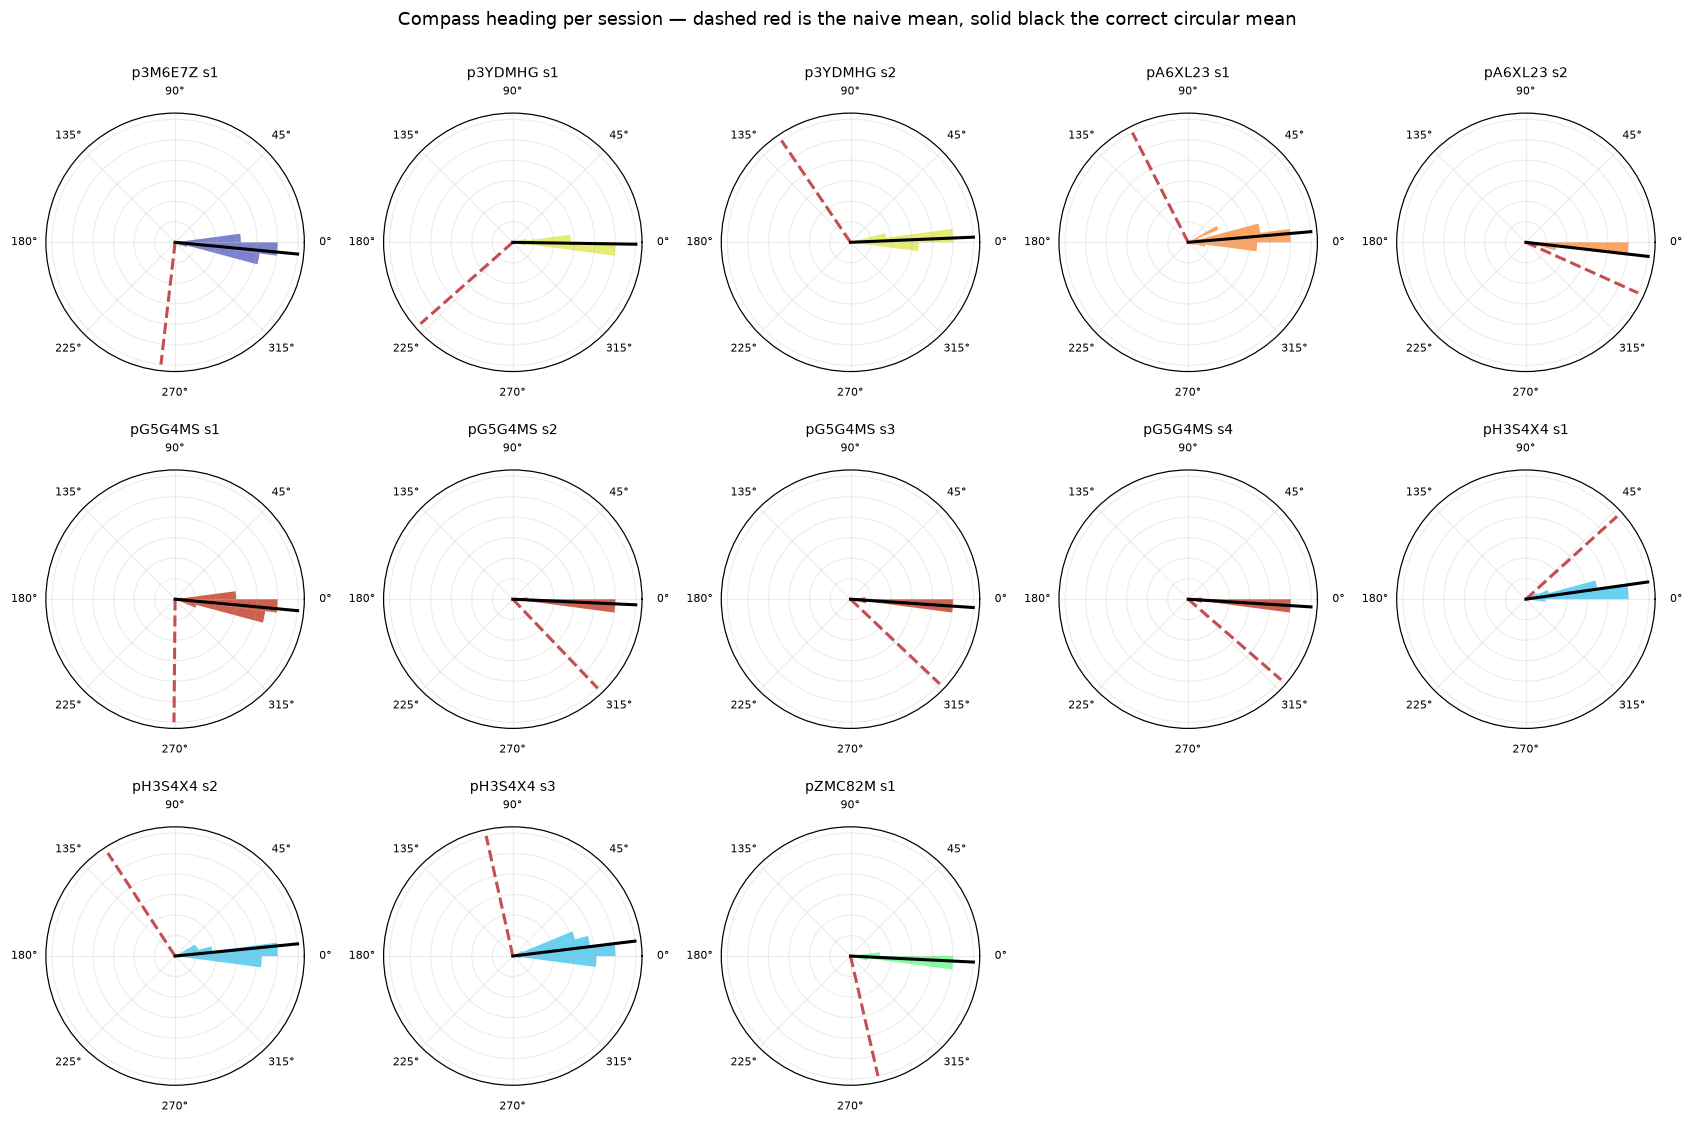

In [30]:
def wrap_table(raw_df):
    rows = []
    for sid in SESSION_ORDER:
        s = raw_df.loc[raw_df['sessionId'] == sid]
        a = pd.to_numeric(s.loc[s['kind'] == ORIENT_KIND, 'payload_alpha'],
                          errors='coerce').dropna().to_numpy()
        if len(a) < 100:
            continue
        ar = np.radians(a)
        circ = float((np.degrees(np.arctan2(np.mean(np.sin(ar)), np.mean(np.cos(ar)))) + 360) % 360)
        naive = float(np.mean(a))
        err = abs(naive - circ)
        rows.append({'session': SESSION_LABEL.get(sid, sid[:8]), 'sessionId': sid, 'n': len(a),
                     'wraps': int((np.abs(np.diff(a)) > 180).sum()),
                     'naive_mean': round(naive, 1), 'circular_mean': round(circ, 1),
                     'error_deg': round(min(err, 360 - err), 1)})
    return pd.DataFrame(rows)


wraps = wrap_table(raw)


def plot_alpha(raw_df, wraps_df):
    sids = wraps_df['sessionId'].tolist()
    ncols = min(5, len(sids)); nrows = int(np.ceil(len(sids) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.1 * ncols, 3.4 * nrows),
                             subplot_kw={'projection': 'polar'}, squeeze=False)
    for ax, sid in zip(axes.ravel(), sids):
        s = raw_df.loc[raw_df['sessionId'] == sid]
        a = pd.to_numeric(s.loc[s['kind'] == ORIENT_KIND, 'payload_alpha'],
                          errors='coerce').dropna().to_numpy()
        ar = np.radians(a)
        counts, edges = np.histogram(ar, bins=48, range=(0, 2 * np.pi))
        ax.bar((edges[:-1] + edges[1:]) / 2, counts / max(counts.max(), 1),
               width=2 * np.pi / 48, color=pcolor(s['participantId'].iloc[0]), alpha=0.7)
        naive = np.radians(np.mean(a))
        circ = np.arctan2(np.mean(np.sin(ar)), np.mean(np.cos(ar)))
        ax.plot([naive, naive], [0, 1.2], color='#c44e52', ls='--', lw=2)
        ax.plot([circ, circ], [0, 1.2], color='black', lw=2)
        ax.set_yticklabels([]); ax.tick_params(labelsize=7)
        ax.set_title(SESSION_LABEL.get(sid, sid[:6]), fontsize=9)
    for ax in axes.ravel()[len(sids):]:
        ax.set_axis_off()
    fig.suptitle("Compass heading per session — dashed red is the naive mean, "
                 "solid black the correct circular mean", y=1.0)
    plt.tight_layout(); plt.show(); plt.close(fig)


print(wraps.drop(columns='sessionId').to_string(index=False))
print(f"\ntotal wraps: {wraps['wraps'].sum()} — every session crosses north repeatedly")
print(f"worst error from naive averaging: {wraps['error_deg'].max():.0f} degrees")
plot_alpha(raw, wraps)

## 10. Two sensors, one quantity

Device attitude is available twice over: from `deviceorientation` directly, and from the
gravity-inclusive accelerometer channels, since gravity always points down and its
direction in device coordinates tells you how the device is tilted.

Comparing them is a free sanity check. Close agreement means both are trustworthy and
that the gravity channels carry no *extra* information about posture. Disagreement would
mean one of them is unreliable — worth knowing before either is used.

   session participantId  from_gravity  from_orientation
p3M6E7Z s1       p3M6E7Z          52.8              52.5
p3YDMHG s1       p3YDMHG          56.1              55.9
p3YDMHG s2       p3YDMHG          54.2              54.2
pA6XL23 s1       pA6XL23          64.6              64.6
pA6XL23 s2       pA6XL23          64.0              63.8
pG5G4MS s1       pG5G4MS          68.8              69.1
pG5G4MS s2       pG5G4MS          39.5              39.8
pG5G4MS s3       pG5G4MS          68.5              68.7
pG5G4MS s4       pG5G4MS          21.9              21.9
pH3S4X4 s1       pH3S4X4          68.5              68.8
pH3S4X4 s2       pH3S4X4          66.4              66.3
pH3S4X4 s3       pH3S4X4          68.2              68.3
pZMC82M s1       pZMC82M          39.8              39.8

agreement: r = +0.9999
The two sensors describe the same physical quantity. The gravity channels are
a redundancy check, not a second source of posture information.


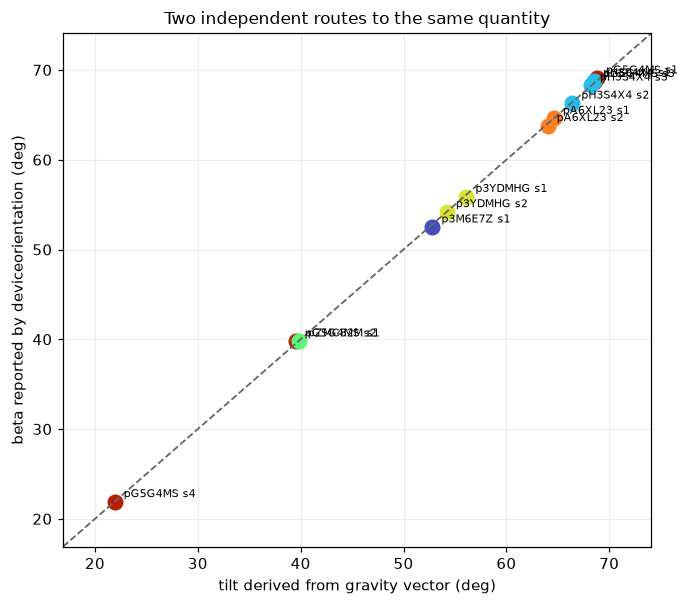

In [31]:
def attitude_check(raw_df):
    rows = []
    for sid in SESSION_ORDER:
        s = raw_df.loc[raw_df['sessionId'] == sid]
        m = s.loc[s['kind'] == MOTION_KIND]
        o = s.loc[s['kind'] == ORIENT_KIND]
        if len(m) < 100 or len(o) < 100:
            continue
        g = {c: pd.to_numeric(m[c], errors='coerce').to_numpy(float) for c in GRAVITY_COLS}
        if any(np.isnan(v).all() for v in g.values()):
            continue
        tilt = np.degrees(np.arctan2(g['payload_agy'],
                                     np.sqrt(g['payload_agx'] ** 2 + g['payload_agz'] ** 2)))
        beta = pd.to_numeric(o['payload_beta'], errors='coerce').to_numpy(float)
        rows.append({'session': SESSION_LABEL.get(sid, sid[:8]),
                     'participantId': s['participantId'].iloc[0],
                     'from_gravity': round(float(abs(np.nanmedian(tilt))), 1),
                     'from_orientation': round(float(np.nanmedian(beta)), 1)})
    return pd.DataFrame(rows)


attitude = attitude_check(raw)


def plot_attitude(att):
    fig, ax = plt.subplots(figsize=(6.4, 5.6))
    for r in att.itertuples():
        ax.scatter(r.from_gravity, r.from_orientation, s=90, color=pcolor(r.participantId))
        ax.annotate(r.session, (r.from_gravity, r.from_orientation), fontsize=7,
                    xytext=(6, 3), textcoords='offset points')
    lims = [min(att[['from_gravity', 'from_orientation']].min()) - 5,
            max(att[['from_gravity', 'from_orientation']].max()) + 5]
    ax.plot(lims, lims, color='0.4', ls='--', lw=1.2)
    ax.set_xlim(*lims); ax.set_ylim(*lims)
    ax.set_xlabel("tilt derived from gravity vector (deg)")
    ax.set_ylabel("beta reported by deviceorientation (deg)")
    ax.set_title("Two independent routes to the same quantity")
    plt.tight_layout(); plt.show(); plt.close(fig)


if len(attitude):
    print(attitude.to_string(index=False))
    r = np.corrcoef(attitude['from_gravity'], attitude['from_orientation'])[0, 1]
    print(f"\nagreement: r = {r:+.4f}")
    print("The two sensors describe the same physical quantity. The gravity channels are")
    print("a redundancy check, not a second source of posture information.")
    plot_attitude(attitude)

## 11. Per-participant summary

Everything above on one page, as descriptive numbers. No scores, no ranking — the point is
to be able to look up what a person's sensors looked like.

Blank cells mean the quantity could not be computed for that person, which is
itself worth noticing.

         sessions  minutes  tilt_deg  tilt_between_session_spread  roll_deg  roll_between_session_spread  idle_epochs  idle_pct  idle_travel_deg_s
p3M6E7Z         1     15.9      52.5                          NaN       0.7                          NaN           32      29.5               7.03
pH3S4X4         3     27.1      68.3                          2.5      -4.0                          5.7            6       1.7               9.94
pZMC82M         1      7.3      39.8                          NaN       3.8                          NaN            8      25.0              10.27
p3YDMHG         2     11.9      55.0                          1.8      -9.0                          0.6           13       8.4               4.91
pA6XL23         2     10.6      64.2                          0.8       2.2                          4.1           17      17.9               7.17
pG5G4MS         

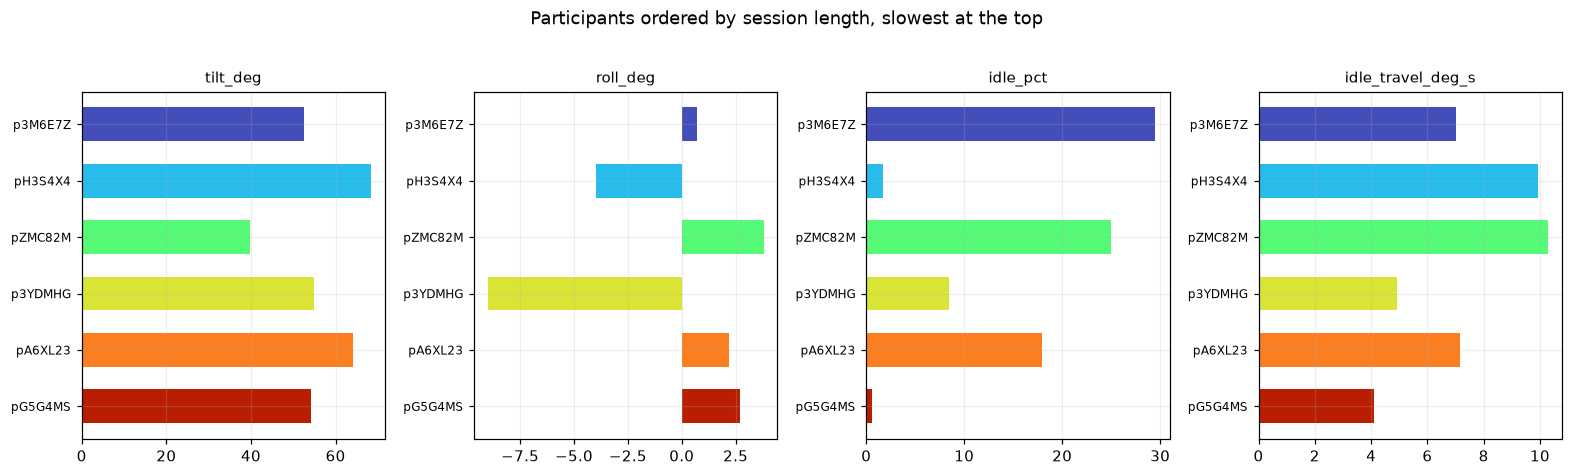

In [32]:
summary = pd.DataFrame(index=PARTICIPANTS)
summary['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
summary['minutes'] = (session_index.groupby('participantId')['duration_s'].sum()
                      .reindex(PARTICIPANTS) / 60).round(1)
for col, short in [('payload_beta', 'tilt'), ('payload_gamma', 'roll')]:
    med, spread = {}, {}
    for p in PARTICIPANTS:
        per_sess = []
        for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
            v = pd.to_numeric(raw.loc[(raw['sessionId'] == sid) & (raw['kind'] == ORIENT_KIND), col],
                              errors='coerce').dropna()
            if len(v) >= MIN_ORIENT:
                per_sess.append(float(v.median()))
        med[p] = round(float(np.median(per_sess)), 1) if per_sess else np.nan
        spread[p] = round(float(max(per_sess) - min(per_sess)), 1) if len(per_sess) > 1 else np.nan
    summary[f'{short}_deg'] = pd.Series(med)
    summary[f'{short}_between_session_spread'] = pd.Series(spread)
summary['idle_epochs'] = avail['idle_epochs'].astype(int)
summary['idle_pct'] = avail['idle_pct_of_session']
if len(idle_dyn):
    summary['idle_travel_deg_s'] = (idle_dyn.groupby('participantId')['angular_travel_deg_s']
                                    .median().reindex(PARTICIPANTS).round(2))

print("Blank cells mean the quantity could not be computed for that person, which is")
print("itself worth noticing.\n")
print(summary.to_string())


def plot_summary(sm):
    cols = [c for c in ['tilt_deg', 'roll_deg', 'idle_pct', 'idle_travel_deg_s'] if c in sm]
    fig, axes = plt.subplots(1, len(cols), figsize=(3.6 * len(cols), 4.2))
    for ax, c in zip(np.atleast_1d(axes), cols):
        v = sm[c].dropna()
        ax.barh(range(len(v)), v, color=[pcolor(p) for p in v.index], height=0.6)
        ax.set_yticks(range(len(v))); ax.set_yticklabels(v.index, fontsize=8)
        ax.invert_yaxis(); ax.set_title(c, fontsize=10)
        miss = [p for p in sm.index if p not in v.index]
        if miss:
            ax.text(0.5, 0.02, f"absent: {', '.join(miss)}", transform=ax.transAxes,
                    ha='center', fontsize=7.5, color='#c44e52')
    fig.suptitle("Participants ordered by session length, slowest at the top", y=1.02)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_summary(summary)

## 12. What the data is like, and what remains open

### Things worth carrying forward about these streams

**Posture is fixed within a session and can differ between sessions.** Section 2 shows
flat traces; Section 4 shows the same person sitting differently on different visits. So
tilt describes the recording at least as much as the person. That is why session-safe
splitting matters: an evaluation that mixes windows from one session across training and
testing would be rewarded for recognising the session.

**Roll behaves differently from tilt.** One participant holds the phone rolled about 9°
one way on both their visits while others sit near zero, and their two sessions agree
closely. Grip may be more personal than posture, but with two sessions for most people
that is an observation rather than a finding.

**Nobody put their phone down.** Every idle acceleration distribution sits in the same
place, well above zero. An earlier guess that one participant's missing tap ring-down
meant a table is not supported by this.

**Movement while idle is not just tapping.** Section 7 compares angular travel during
interaction against during idle, and the idle bars are well above zero — there is genuine
hand movement underneath the interaction.

**The fastest participant cannot be described by any idle measure.** Not a data fault. It
is what "never stops interacting" looks like in a table.

### Data-quality notes

- **`alpha` wraps constantly** and averaging it naively is wrong by up to 137°. Anything
  circular needs sin/cos treatment.
- **Gravity channels duplicate `deviceorientation`** at r ≈ 1.0. Useful as a cross-check,
  not as extra information.
- **The sampling rate puts hand tremor at or past the Nyquist limit**, so high-frequency
  energy is partly aliased. Raising the motion rate would be the single change that most
  improves what this notebook can see.

### Open questions the data cannot currently answer

- Is roll stable over more than two sessions, or does it drift like tilt does?
- Does idle restlessness mean anything about a person, or does it mostly track how
  comfortable they were that day? Repeat sessions under different conditions would
  separate those.
- Would a higher motion sample rate reveal structure in the fast band that is currently
  folded down and unreadable?
- Everyone here is on their own handset, so any sensor difference between people is also
  a difference between devices. Shared-device data is what separates those.


In [33]:
OUT_DIR = Path("../../data/interim")
OUT_DIR.mkdir(parents=True, exist_ok=True)

_exports = {
    'posture_session_angles.csv': angle_summary,
    'posture_windows.csv': windows,
    'posture_idle_runs.csv': runs,
    'posture_idle_dynamics.csv': idle_dyn,
    'posture_alpha_wraps.csv': wraps,
    'posture_attitude_crosscheck.csv': attitude,
    'posture_participant_summary.csv': summary.reset_index().rename(columns={'index': 'participantId'}),
}
for name, frame in _exports.items():
    frame.to_csv(OUT_DIR / name, index=False)
    print(f"wrote {OUT_DIR / name}  ({len(frame):,} rows)")

wrote ../../data/interim/posture_session_angles.csv  (13 rows)
wrote ../../data/interim/posture_windows.csv  (1,851 rows)
wrote ../../data/interim/posture_idle_runs.csv  (77 rows)
wrote ../../data/interim/posture_idle_dynamics.csv  (77 rows)
wrote ../../data/interim/posture_alpha_wraps.csv  (13 rows)
wrote ../../data/interim/posture_attitude_crosscheck.csv  (13 rows)
wrote ../../data/interim/posture_participant_summary.csv  (6 rows)
